# Junction core block clustering and diversity
Cluster junction by core genome diversity and define insertions, deletions, translocations and inversions.

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction

In [2]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,18953,18189.108108,218,16280.0,1698.0,False,727.5,0.018018
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,12516,11742.500000,221,1529.0,10210.0,False,777.0,0.004505
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,29386,27955.472973,221,23708.0,4241.0,False,1437.0,0.004505
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,8141,7371.000000,220,2780.0,4584.0,False,777.0,0.009009
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,48231,10227.959459,221,7295.0,2761.0,False,38175.0,0.004505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,105312,85545.500000,0,18605.0,29023.0,False,35067.5,1.000000
544,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,False,1,2,False,0.000000,1,7230,7230,7230.000000,2,7230.0,7230.0,True,NaN,0.000000
545,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,83629,83629.000000,2,31644.0,48920.0,False,NaN,0.000000
546,YUOECYBHUS_f__ZTHKZYHPIX_f,2,20,True,2,1,True,0.693147,35,66709,186025,126367.000000,0,60231.0,5710.0,False,60426.0,1.000000


In [3]:
clustering_results = {}

for junction_id in jdf["edge"].tolist():
    print(junction_id)
    cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core(junction_id, plot_consensus=False, plot_pair_dist=False, plot_snp_dist= False, plot_ambiguities= False, clustering_bl_thresh=0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')
    clustering_results[junction_id] = cluster_map_core

    # determine insertions, deletions, inversions, translocations for each consensus path
    example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")

    for i in range(1, len(consensus_paths_plotting) + 1):
        insertions, deletions, inversions, translocations = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
        summarize_inversions_consensus(inversions, junction_id, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/inversions", save_df=True)
        summarize_translocations_consensus(translocations, junction_id, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/translocations", save_df=True)
        write_insertions_fasta(junction_id, example_pangraph, insertions, consensus = i, save_df=True)
        deletions_df = summarize_deletions_consensus(deletions, junction_id, example_pangraph, path_dict, assignment_df_plotting, consensus_id=i, parent_dir = "../results/atb_lookup/deletions", rerun_alignment=False, save_df=True)

    load_all_translocations_summaries("../results/atb_lookup/translocations", junction_id, save_df=True)
    load_all_insertions_summaries("../results/atb_lookup/insertions", junction_id, save_df=True)
    load_all_inversions_summaries("../results/atb_lookup/inversions", junction_id, save_df=True)
    load_all_deletions_summaries("../results/atb_lookup/deletions", junction_id, save_df=True)

# 8 min after alignment has been prerun, more than an hour if core alignments have to be run

HUTOPWFGVH_f__WJBYSSJHSE_f
Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/HUTOPWFGVH_f__WJBYSSJHSE_f
[{1}, {1}, {1}, {0}, {0}]
No ambiguous blocks.
222 / 222 isolates share the majority path
Insertions:
NZ_AP026788.1 INSERTED: [11271243518245960494|+|]
NZ_AP026794.1 INSERTED: [11271243518245960494|+|]
NZ_CP102947.1 INSERTED: [7811279214181103925|+|]
NZ_CP059130.1 INSERTED: [11271243518245960494|+|]
No inversions found for consensus_1, nothing saved.
No translocations found for consensus_1, nothing saved.
No deletions found for consensus_1, nothing saved.
IZQZNHJQRQ_f__ZVPGGEJIIF_f
Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/IZQZNHJQRQ_f__ZVPGGEJIIF_f
[{1}, {1}, {0}]
No ambiguous blocks.
222 / 222 isolates share the majority path
Insertions:
NZ_CP051615.1 INSERTED: [1514117989414

In [9]:
import subprocess
subprocess.run(["mafft", "--version"])

v7.526 (2024/Apr/26)


CompletedProcess(args=['mafft', '--version'], returncode=0)

Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1775: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



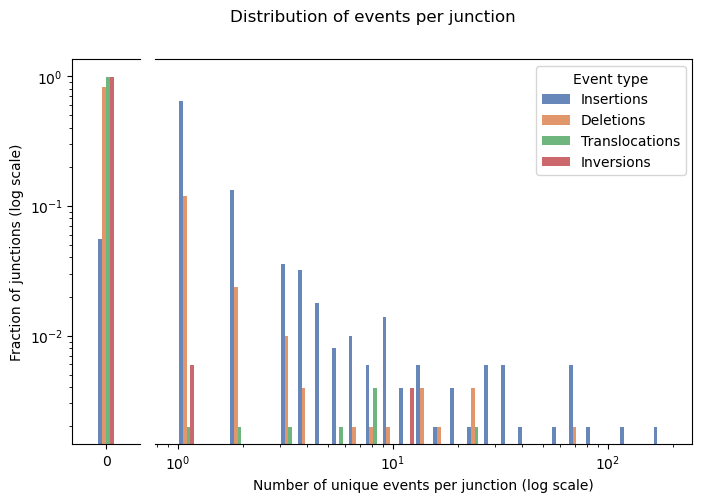

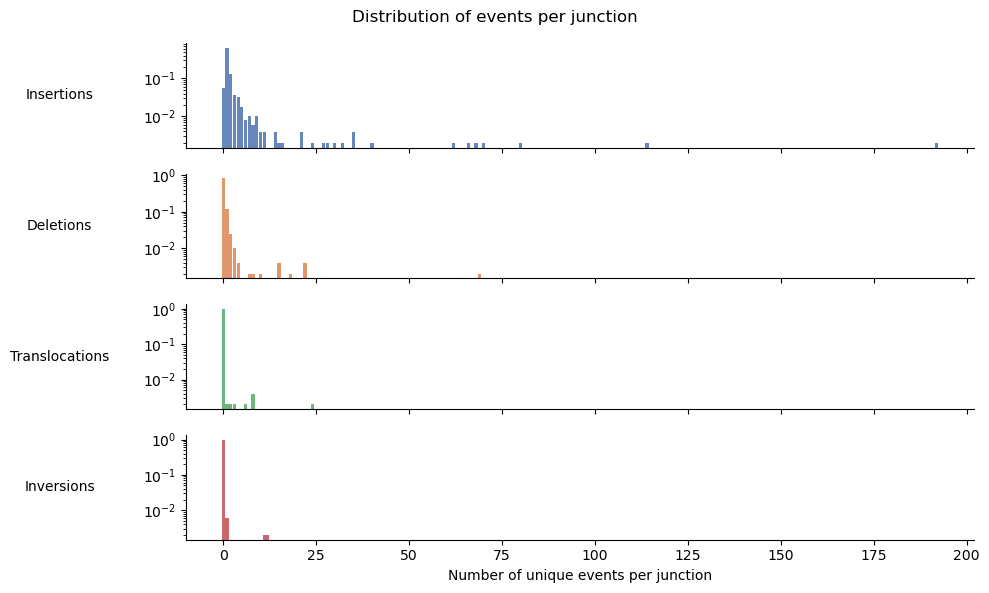

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1657: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



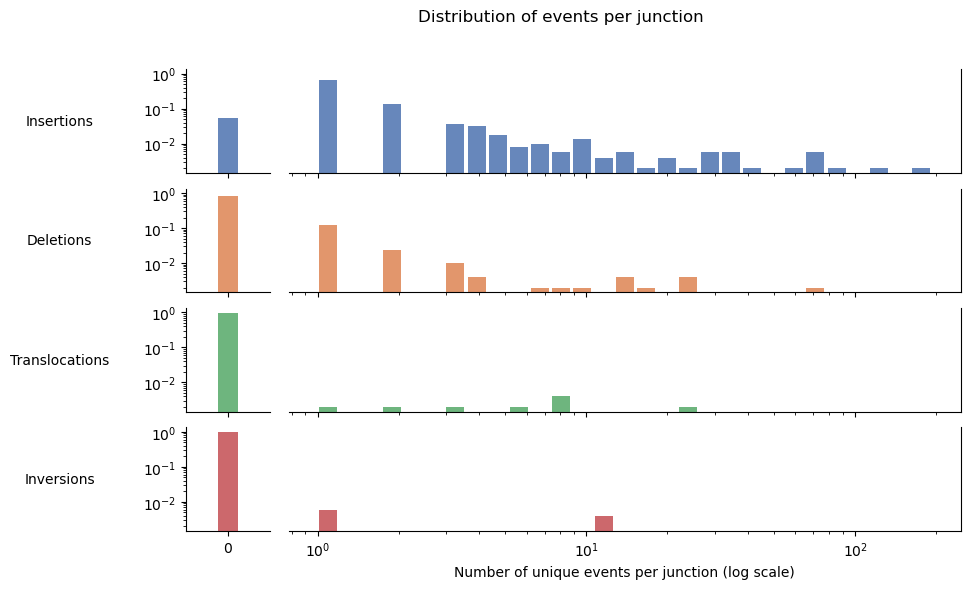

In [2]:
summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=True)  
counts_df = count_events_per_junction(summaries, min_length=200, save_path="../results/atb_lookup/event_counts_per_junction.csv")  
plot_event_counts_distribution(counts_df, figsize=(8, 5), log_scale = True)
plot_event_counts_distribution(counts_df, figsize=(10, 6), log_scale=False, subplots = True)
plot_event_counts_distribution(counts_df, figsize=(10, 6), log_scale=True, subplots = True)

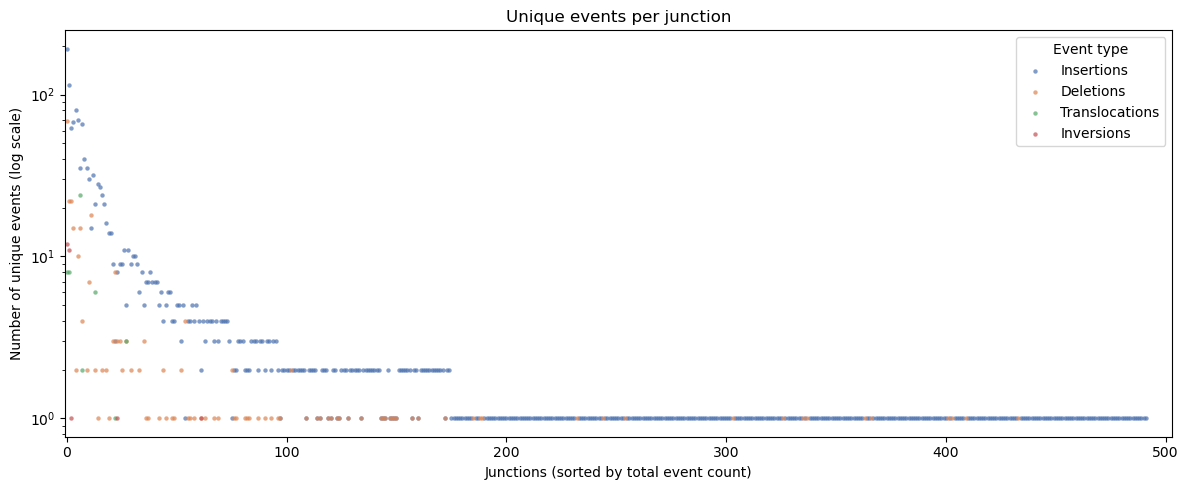

In [ ]:
plot_events_per_junction(counts_df)

In [ ]:
summaries['inversions']

,junction_name,consensus,genome_name,path,inversion,length,start_pos,end_pos,strand
0,EJPOGALASQ_f__KUIFCLFQSI_r,consensus_1,NZ_CP124500.1,[1313223200582472894|-|],inversion0,246,57347,57593,-
1,IMAMHFLCWS_f__RKAOKULCFF_f,consensus_1,NZ_CP098203.1,[8559478569508182595|-|]_[5886313610618781876|...,inversion0,1400,17575,18975,-
2,JVNRLCFAVD_f__ZTHKZYHPIX_f,consensus_1,NZ_CP107182.1,[10380304388000818034|-|17257808738712551941_1...,inversion0,3557,36381,41716,-
3,NOAJDCSIVA_f__NZXBIFMPMA_r,consensus_1,NZ_CP021179.1,[17087090671956307015|-|],inversion0,1361,18640,20001,-
4,NOAJDCSIVA_f__NZXBIFMPMA_r,consensus_1,NZ_AP022549.1,[17087090671956307015|-|],inversion0,1361,18640,20001,-
...,...,...,...,...,...,...,...,...,...
59,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,NZ_AP022362.1,[14278357606779827683|+|3719368368610427324_1]...,inversion0,768,13992,14760,+
60,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,NZ_OX637964.1,[12328260769168341665|-|]_[7177061195065662354...,inversion0,25526,15798,41324,-
61,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,NZ_CP124460.1,[14278357606779827683|+|17687220482716050848_1...,inversion0,760,14457,15217,+
62,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,NZ_CP027534.1,[14278357606779827683|+|15908320088543975006_1...,inversion0,775,14957,18264,+


In [ ]:
clustering_results

{'HUTOPWFGVH_f__WJBYSSJHSE_f': {'NZ_CP020116.1': 0,
  'NZ_CP028483.1': 0,
  'NZ_LS992190.1': 0,
  'NZ_CP024720.1': 0,
  'NZ_CP027534.1': 0,
  'NZ_CP096110.1': 0,
  'NZ_CP049077.2': 0,
  'NZ_CP104846.1': 0,
  'NZ_AP022525.1': 0,
  'NZ_CP103557.1': 0,
  'NZ_CP107120.1': 0,
  'NZ_OW968277.1': 0,
  'NZ_CP103508.1': 0,
  'NZ_CP107174.1': 0,
  'NZ_AP022044.1': 0,
  'NZ_CP103672.1': 0,
  'NZ_LS992168.1': 0,
  'NZ_CP080116.1': 0,
  'NZ_LS999560.1': 0,
  'NZ_CP116181.1': 0,
  'NZ_CP124328.1': 0,
  'NZ_LR130545.1': 0,
  'NZ_LS992180.1': 0,
  'NZ_CP032201.1': 0,
  'NZ_AP026788.1': 0,
  'NZ_CP128947.1': 0,
  'NZ_AP026794.1': 0,
  'NZ_CP019015.1': 0,
  'NZ_LS992192.1': 0,
  'NZ_CP080117.1': 0,
  'NZ_CP069583.1': 0,
  'NZ_CP082831.1': 0,
  'NZ_CP107114.1': 0,
  'NZ_CP103562.1': 0,
  'NZ_CP133927.1': 0,
  'NZ_CP103755.1': 0,
  'NZ_CP041337.1': 0,
  'NZ_CP080118.1': 0,
  'NZ_AP022326.1': 0,
  'NZ_CP019012.1': 0,
  'NZ_CP104848.1': 0,
  'NZ_CP103710.1': 0,
  'NZ_CP024717.1': 0,
  'NZ_CP107128.1': 0,
  

In [ ]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core(junction_name, plot_consensus=True, plot_pair_dist=False, plot_ambiguities=False, clustering_bl_thresh=0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')


Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/KGJXRPELGX_r__KIVDDRSTJR_r
[{1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
207 / 215 isolates share the majority path


In [ ]:
#junction_name = 'KGJXRPELGX_r__KIVDDRSTJR_r'
#junction_name = 'JVNRLCFAVD_f__ZTHKZYHPIX_f'
junction_name = "OWCPAELREV_r__YGYJJNMGPS_r"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

plot_junction_pangraph_interactive(
            pangraph,
            show_consensus=False,
            order="tree",
            title = ""
        )

In [ ]:
for path in pangraph.paths:
    print(path.nuc_len)
    break

6004


In [ ]:
junction_name = 'DSLXSJZSTL_r__KGJXRPELGX_f'
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

plot_junction_pangraph_interactive(
            pangraph,
            show_consensus=False,
            order="tree",
            title = ""
        )
pangraph.to_blockstats_df()

,count,n_strains,duplicated,core,len
block_id,,,,,
4241624576497585751,2,2,False,True,2186
8525864575675374872,2,2,False,True,901
11623781417307966939,1,1,False,False,2600
14884967353754294855,2,2,False,True,3165
15320439524446504128,9,2,True,False,820
16225107807931665320,2,2,False,True,6426
17939975761913636107,2,2,False,True,1133


In [ ]:
jdf[jdf['edge'] == 'DSLXSJZSTL_r__KGJXRPELGX_f']

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,pangenome_len
540,DSLXSJZSTL_r__KGJXRPELGX_f,2,7,True,2,1,True,0.693147,20,17092,20512,18802.0,0,1134.0,6426.0,False,4990.0,1.0,14789.0


In [ ]:
for block in pangraph.blocks:
    print(block)

block 1340408361165795816, consensus len = 6093 bp, n. nodes = 222


In [ ]:
jdf[jdf['edge'] == 'OWCPAELREV_r__YGYJJNMGPS_r']

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,pangenome_len
158,OWCPAELREV_r__YGYJJNMGPS_r,222,4,False,3,168,False,0.577221,8,6095,6242,6121.684685,168,3556.0,2539.0,False,109.703704,0.243243,145.0


In [ ]:
# 29 junctions have only one block
jdf[jdf['n_blocks'] == 1]

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,pangenome_len
12,JDUTVQBTFB_f__YOJVMARYCH_f,222,1,False,1,222,False,0.0,1,44037,44037,44037.0,222,44037.0,44037.0,True,NaN,0.0,5354.0
93,HAEXIMTKOL_f__WOHPWXHUSI_f,222,1,False,1,222,False,0.0,1,12072,12072,12072.0,222,12072.0,12072.0,True,NaN,0.0,492.0
94,HOIZZDAEJL_f__VGYXZAWOLD_f,222,1,False,1,222,False,0.0,1,29541,29541,29541.0,222,29541.0,29541.0,True,NaN,0.0,1186.0
117,IANJWCNSRC_f__YXSCHJRBEK_f,222,1,False,1,222,False,0.0,1,9221,9221,9221.0,222,9221.0,9221.0,True,NaN,0.0,645.0
174,QBLLBRLBSY_f__WVXKPXNUHD_f,222,1,False,1,222,False,0.0,1,34273,34273,34273.0,222,34273.0,34273.0,True,NaN,0.0,5354.0
185,PJYKOTQZCQ_f__XNUJCMVIGS_f,222,1,False,1,222,False,0.0,1,6529,6529,6529.0,222,6529.0,6529.0,True,NaN,0.0,1164.0
236,MQQJQQCKYE_r__NSABNEFPLA_r,222,1,False,1,222,False,0.0,1,36971,36971,36971.0,222,36971.0,36971.0,True,NaN,0.0,5354.0
287,CURWDAFDCZ_f__SOPFFTTIKI_r,222,1,False,1,222,False,0.0,1,15793,15793,15793.0,222,15793.0,15793.0,True,NaN,0.0,5264.0
330,ALEITXQZYY_r__DRPPNPOGXL_r,222,1,False,1,222,False,0.0,1,11693,11693,11693.0,222,11693.0,11693.0,True,NaN,0.0,1073.0
360,BAJXPSVBKO_r__KUYFFMDYBH_r,222,1,False,1,222,False,0.0,1,5999,5999,5999.0,222,5999.0,5999.0,True,NaN,0.0,974.0


In [ ]:
for junction_id in jdf["edge"].tolist():
    pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")
    bs_df = pangraph.to_blockstats_df()
    n_core = len(bs_df[bs_df['core'] == True])
    if n_core != 2:
        print(junction_id, n_core)

# 114 junctions have not exactly 2 core blocks (some have 3, 4, 5, or 6 and some have only 1, always at least 1)

HUTOPWFGVH_f__WJBYSSJHSE_f 3
JJDDCMJGQE_r__ZUHGCANVTN_r 4
JJDDCMJGQE_f__PJYKOTQZCQ_f 3
JDUTVQBTFB_f__YOJVMARYCH_f 1
IZPPAJHCDB_f__OOKLAQXFLW_f 4
IZBYPELCGF_f__YNTFBMKXBV_f 3
SUTPFZJSZW_r__XWQYUUGDGN_r 3
KPBYGJHRZJ_f__PTUISUDLZT_f 4
KLARMMLEPU_r__WBEPREVZIH_f 3
RYYAQMEJGY_f__XKJZBXCDPZ_f 3
JSJIXCXPII_f__QQTMQNQWDS_r 3
KDNDVPYXTO_f__WXGURNWKVZ_f 4
KCBEPSEUCA_f__RPRBRFQSUF_f 3
KAIPBNCIHR_r__WXCHSHHCDT_f 3
KAIPBNCIHR_f__ZWPXXGKXGL_r 3
SOPFFTTIKI_r__XPVMPHROHI_r 3
IOOFKXBSGN_r__WGHTAJLAAQ_r 3
HMGOSWQWLP_r__SHLDLTAVZA_r 4
HLLLVEXLHF_r__NBVDTPUFKL_f 3
HLDRILYIZH_f__XNYZXWCUST_f 3
HEDBBNUKLU_r__VSCDQDGRHO_r 4
HAEXIMTKOL_f__WOHPWXHUSI_f 1
HOIZZDAEJL_f__VGYXZAWOLD_f 1
IIFSSHHHUK_f__RJJWLWHZAS_f 3
IAOFBOJKOX_f__NSJRIJGVOG_r 4
IANJWCNSRC_f__YXSCHJRBEK_f 1
IAMXLIYGOQ_r__WXGURNWKVZ_r 3
OBEJYXNUDN_r__ZTHKZYHPIX_r 3
OSURYAORCR_f__RVLRLPDSYQ_r 3
OLUEEZMVIH_r__PWDSOBLBPO_r 3
OHDZQPGPWN_f__YVITOTFSEE_f 3
NXMETPNVGP_f__WYYPRCOBHQ_r 4
NOAJDCSIVA_f__NZXBIFMPMA_r 3
OWCPAELREV_r__YGYJJNMGPS_r 1
QSECVMMRIA_r__

In [ ]:
for junction_id in jdf["edge"].tolist():
    pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")
    bs_df = pangraph.to_blockstats_df()
    if len(bs_df[(bs_df['core'] == True) & (bs_df['duplicated'] == True)]) > 0:
        print(junction_id)
        print(bs_df)

In [ ]:
junction_name = 'JVNRLCFAVD_f__ZTHKZYHPIX_f'
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

bs_df = pangraph.to_blockstats_df()

# 10380304388000818034 block of JVNRLCFAVD_f__ZTHKZYHPIX_f junction is in all three isolates but still not core 

In [ ]:
len(bs_df[(bs_df['core'] == True) & (bs_df['duplicated'] == True)])

0

In [ ]:

# TODO: currently I don't take care of strandedness within deletions, they might have some inverted and some not inverted blocks based on the consensus path
# deletions are split now but the summary code is not yet inverting deletions
# should work now, still test

# in the case of unique blogs, I'm assuming that they were insertions (even though we can't know for sure) --> ancestral state 0
# TODO add top down approach for fitch algorithm


# TODO: deletions problem was that blocks were added multiple times if they are duplicated blocks, deletions analysis has to be rerun, check that has been fixed

# TODO: think about inversions when working with core blocks, I think they are never inverted, ask

# TODO: when defining insertions and deletions rightnow inversions are found as insertions and deletions because they have different context than if the sequence would not be inverted, additionally blocks in between invertions become insertions because they can't get the inverted part as context while non-inverted parts can be consensus
# --> potentially need to make possibly inverted blocks never context
# if they are duplicated they might not even have context --> less problematic
# there can be inversions where some blocks are duplicated and some aren't 


In [ ]:
len(np.unique(list(cluster_map_core.values())))

In [ ]:
# TODO: how do I measure junction diversity
# average pairwise block jaccard distance?
# maybe compare to cat_entropy of each junction